In [19]:
# ============================================================
# CELL 1 — LOAD EXTRACTION RESULTS
# ============================================================

from pathlib import Path
import pickle

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import py4dgeo


# ------------------------------------------------------------
# Repository and evaluation paths
# ------------------------------------------------------------

CURRENT_DIR = Path.cwd()

if CURRENT_DIR.name == "jupyter":
    REPO_DIR = CURRENT_DIR.parent
else:
    REPO_DIR = CURRENT_DIR


DATA_DIR = (
    REPO_DIR
    / "kijkduin"
)


EVALUATION_DIR = (
    REPO_DIR
    / "results"
    / "kalman_evaluation"
)


ANALYSIS_FILE = (
    DATA_DIR
    / "kijkduin.zip"
)


OBJECTS_FILE = (
    EVALUATION_DIR
    / "extracted_objects.pkl"
)


SUMMARY_FILE = (
    EVALUATION_DIR
    / "method_summary.csv"
)


# ------------------------------------------------------------
# Validate required files
# ------------------------------------------------------------

for file_path in [
    ANALYSIS_FILE,
    OBJECTS_FILE,
    SUMMARY_FILE,
]:

    if not file_path.exists():
        raise FileNotFoundError(
            f"Required file not found:\n"
            f"{file_path}\n\n"
            "Run the previous notebooks first."
        )


# ------------------------------------------------------------
# Load analysis archive
# ------------------------------------------------------------

analysis = (
    py4dgeo.SpatiotemporalAnalysis(
        str(
            ANALYSIS_FILE
        )
    )
)


# ------------------------------------------------------------
# Load extracted objects
# ------------------------------------------------------------

with open(
    OBJECTS_FILE,
    "rb"
) as file:

    extracted_objects = (
        pickle.load(
            file
        )
    )


# ------------------------------------------------------------
# Load method summary
# ------------------------------------------------------------

method_summary = pd.read_csv(
    SUMMARY_FILE
)


# ------------------------------------------------------------
# Analysis timestamps and corepoints
# ------------------------------------------------------------

timestamps_analysis = [
    analysis.reference_epoch.timestamp
    + time_delta
    for time_delta
    in analysis.timedeltas
]


corepoints = np.asarray(
    analysis.corepoints.cloud
)


# ------------------------------------------------------------
# Verification
# ------------------------------------------------------------

display(
    method_summary
)

[2026-08-23 16:08:07][INFO] Restoring epoch from file 'C:\Users\tenbi\AppData\Local\Temp\tmpjbr_f8gh\reference_epoch.zip'
[2026-08-23 16:08:08][INFO] Restoring epoch from file 'C:\Users\tenbi\AppData\Local\Temp\tmpunljoq1k\corepoints.zip'


,method,n_seeds,n_objects
0,4DOBC,2348,17
1,KF-Mag,3117,15
2,KF-Rate,3719,23
3,KF-Mag-NMS,101,8
4,KF-Rate-NMS,128,11


In [20]:
# ============================================================
# CELL 2 — OBJECT COMPARISON FUNCTIONS
# ============================================================

def temporal_overlap_epochs(
    reference_object,
    candidate_object
):
    """
    Number of overlapping epochs between two objects.
    """

    overlap = max(
        0,

        min(
            reference_object[
                "end_epoch"
            ],
            candidate_object[
                "end_epoch"
            ]
        )

        -

        max(
            reference_object[
                "start_epoch"
            ],
            candidate_object[
                "start_epoch"
            ]
        )

        + 1
    )

    return int(
        overlap
    )


def spatial_overlap_count(
    reference_object,
    candidate_object
):
    """
    Number of shared corepoints between two objects.
    """

    reference_indices = set(
        reference_object[
            "indices"
        ]
    )

    candidate_indices = set(
        candidate_object[
            "indices"
        ]
    )

    return len(
        reference_indices
        & candidate_indices
    )


def spatial_iou(
    reference_object,
    candidate_object
):
    """
    Spatial intersection-over-union of object corepoints.
    """

    reference_indices = set(
        reference_object[
            "indices"
        ]
    )

    candidate_indices = set(
        candidate_object[
            "indices"
        ]
    )

    union = (
        reference_indices
        | candidate_indices
    )

    if len(union) == 0:
        return 0.0

    return (
        len(
            reference_indices
            & candidate_indices
        )
        / len(
            union
        )
    )


def temporal_iou(
    reference_object,
    candidate_object
):
    """
    Temporal intersection-over-union of object epoch intervals.
    """

    intersection = temporal_overlap_epochs(
        reference_object,
        candidate_object
    )

    union_start = min(
        reference_object[
            "start_epoch"
        ],
        candidate_object[
            "start_epoch"
        ]
    )

    union_end = max(
        reference_object[
            "end_epoch"
        ],
        candidate_object[
            "end_epoch"
        ]
    )

    union = (
        union_end
        - union_start
        + 1
    )

    if union <= 0:
        return 0.0

    return (
        intersection
        / union
    )

In [21]:
# ============================================================
# CELL 3 — RANK MATCHES AGAINST ORIGINAL 4DOBC
# ============================================================

comparison_methods = [
    "KF-Mag",
    "KF-Rate",
    "KF-Mag-NMS",
    "KF-Rate-NMS",
]


reference_objects = (
    extracted_objects[
        "4DOBC"
    ]
)


# ------------------------------------------------------------
# Load Kalman seed tables once
# ------------------------------------------------------------

seed_tables = {
    "KF-Mag":
        pd.read_csv(
            EVALUATION_DIR
            / "kf_mag_seeds.csv"
        ),

    "KF-Rate":
        pd.read_csv(
            EVALUATION_DIR
            / "kf_rate_seeds.csv"
        ),

    "KF-Mag-NMS":
        pd.read_csv(
            EVALUATION_DIR
            / "kf_mag_nms_seeds.csv"
        ),

    "KF-Rate-NMS":
        pd.read_csv(
            EVALUATION_DIR
            / "kf_rate_nms_seeds.csv"
        ),
}


# ------------------------------------------------------------
# Build ranked candidate matches
# ------------------------------------------------------------

all_match_records = []


for method_name in comparison_methods:

    candidate_objects = (
        extracted_objects[
            method_name
        ]
    )

    seed_table = (
        seed_tables[
            method_name
        ]
    )


    for reference_object in reference_objects:

        reference_number = int(
            reference_object[
                "object_number"
            ]
        )

        candidate_records = []


        for candidate_object in candidate_objects:

            temporal_overlap = (
                temporal_overlap_epochs(
                    reference_object,
                    candidate_object
                )
            )


            spatial_overlap = (
                spatial_overlap_count(
                    reference_object,
                    candidate_object
                )
            )


            # ------------------------------------------------
            # Match candidate object to its generating seed
            # ------------------------------------------------

            mask = (
                seed_table[
                    "corepoint_index_python"
                ]
                ==
                int(
                    candidate_object[
                        "seed_corepoint"
                    ]
                )
            )


            mask &= (
                seed_table[
                    "start_epoch"
                ]
                ==
                int(
                    candidate_object[
                        "seed_start_epoch"
                    ]
                )
            )


            mask &= (
                seed_table[
                    "end_epoch"
                ]
                ==
                int(
                    candidate_object[
                        "seed_end_epoch"
                    ]
                )
            )


            matches = (
                seed_table[
                    mask
                ]
            )


            if len(matches) > 0:

                event_magnitude = float(
                    matches.iloc[0][
                        "event_magnitude"
                    ]
                )

            else:

                event_magnitude = np.nan


            candidate_records.append(
                {
                    "reference_method":
                        "4DOBC",

                    "reference_object":
                        reference_number,

                    "candidate_method":
                        method_name,

                    "candidate_object":
                        int(
                            candidate_object[
                                "object_number"
                            ]
                        ),

                    "temporal_overlap_epochs":
                        temporal_overlap,

                    "spatial_overlap_corepoints":
                        spatial_overlap,

                    "temporal_iou":
                        temporal_iou(
                            reference_object,
                            candidate_object
                        ),

                    "spatial_iou":
                        spatial_iou(
                            reference_object,
                            candidate_object
                        ),

                    "event_magnitude":
                        event_magnitude,

                    "seed_duration_epochs":
                        int(
                            candidate_object[
                                "seed_duration_epochs"
                            ]
                        ),
                }
            )


        candidate_table = pd.DataFrame(
            candidate_records
        )


        if len(candidate_table) == 0:
            continue


        # ----------------------------------------------------
        # Ranking logic
        #
        # 1. Largest temporal overlap
        # 2. Largest spatial overlap
        # 3. Largest event magnitude
        # 4. Longest seed duration
        # ----------------------------------------------------

        candidate_table = (
            candidate_table
            .sort_values(
                [
                    "temporal_overlap_epochs",
                    "spatial_overlap_corepoints",
                    "event_magnitude",
                    "seed_duration_epochs",
                ],
                ascending=[
                    False,
                    False,
                    False,
                    False,
                ]
            )
            .reset_index(
                drop=True
            )
        )


        candidate_table[
            "match_rank"
        ] = np.arange(
            1,
            len(
                candidate_table
            )
            + 1
        )


        all_match_records.extend(
            candidate_table.to_dict(
                orient="records"
            )
        )


# ------------------------------------------------------------
# Combined ranked match table
# ------------------------------------------------------------

match_table = pd.DataFrame(
    all_match_records
)


display(
    match_table.head(
        20
    )
)

,reference_method,reference_object,candidate_method,candidate_object,temporal_overlap_epochs,spatial_overlap_corepoints,temporal_iou,spatial_iou,event_magnitude,seed_duration_epochs,match_rank
0,4DOBC,1,KF-Mag,2,19,2711,0.513514,0.661381,1.074054,37,1
1,4DOBC,1,KF-Mag,3,19,740,0.612903,0.085126,0.654558,31,2
2,4DOBC,1,KF-Mag,11,19,1,0.395833,0.000151,0.496794,48,3
3,4DOBC,1,KF-Mag,4,0,1749,0.000000,0.143021,0.575651,37,4
4,4DOBC,1,KF-Mag,6,0,1310,0.000000,0.173235,0.414795,23,5
5,4DOBC,1,KF-Mag,1,0,1075,0.000000,0.132749,0.817376,35,6
6,4DOBC,1,KF-Mag,5,0,972,0.000000,0.210026,0.424009,57,7
7,4DOBC,1,KF-Mag,8,0,565,0.000000,0.133318,0.146422,31,8
8,4DOBC,1,KF-Mag,10,0,167,0.000000,0.034937,0.252642,53,9
9,4DOBC,1,KF-Mag,15,0,25,0.000000,0.006509,0.051804,10,10


In [22]:
# ============================================================
# CELL 4 — BEST MATCH FOR EACH ORIGINAL OBJECT
# ============================================================

best_matches = (
    match_table[
        match_table[
            "match_rank"
        ]
        == 1
    ]
    .copy()
)


best_matches = (
    best_matches
    .sort_values(
        [
            "reference_object",
            "candidate_method",
        ]
    )
    .reset_index(
        drop=True
    )
)


print(
    "Rank-1 candidates according to the defined "
    "temporal/spatial/magnitude/duration ranking."
)


display(
    best_matches
)


best_matches.to_csv(
    EVALUATION_DIR
    / "best_object_matches.csv",
    index=False
)

Rank-1 candidates according to the defined temporal/spatial/magnitude/duration ranking.


,reference_method,reference_object,candidate_method,candidate_object,temporal_overlap_epochs,spatial_overlap_corepoints,temporal_iou,spatial_iou,event_magnitude,seed_duration_epochs,match_rank
0,4DOBC,1,KF-Mag,2,19,2711,0.513514,0.661381,1.074054,37,1
1,4DOBC,1,KF-Mag-NMS,1,19,2624,0.542857,0.593934,1.045193,35,1
2,4DOBC,1,KF-Rate,18,10,0,0.526316,0.000000,0.443434,10,1
3,4DOBC,1,KF-Rate-NMS,4,14,2322,0.437500,0.491221,0.120325,27,1
4,4DOBC,2,KF-Mag,1,15,5125,0.428571,0.880584,0.817376,35,1
...,...,...,...,...,...,...,...,...,...,...,...
63,4DOBC,16,KF-Rate-NMS,7,21,0,0.280000,0.000000,0.141048,21,1
64,4DOBC,17,KF-Mag,9,16,0,0.592593,0.000000,0.061109,16,1
65,4DOBC,17,KF-Mag-NMS,1,11,123,0.215686,0.035386,1.045193,35,1
66,4DOBC,17,KF-Rate,2,10,0,0.322581,0.000000,1.039159,14,1


,method,n_seeds,n_objects
0,4DOBC,2348,17
1,KF-Mag,3117,15
2,KF-Rate,3719,23
3,KF-Mag-NMS,101,8
4,KF-Rate-NMS,128,11


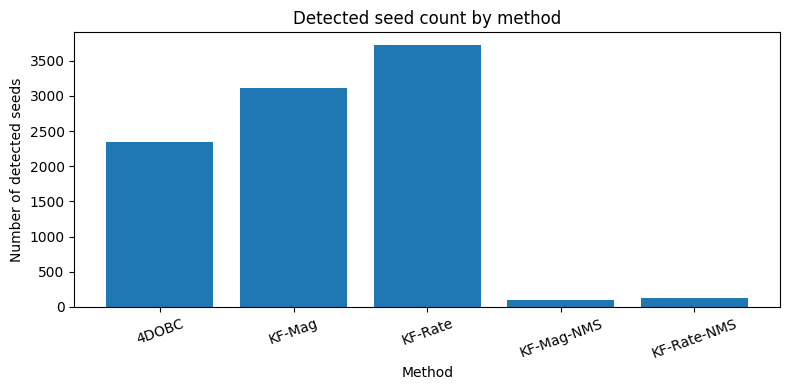

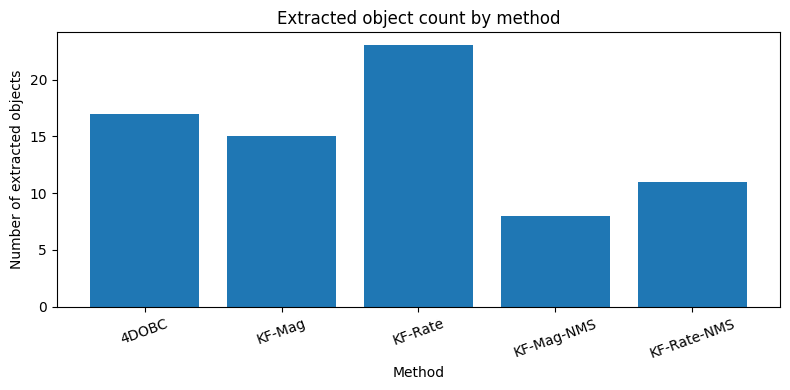

In [23]:
# ============================================================
# CELL 5 — SEED AND OBJECT COUNTS
# ============================================================

# ------------------------------------------------------------
# Numerical summary
# ------------------------------------------------------------

display(
    method_summary
)


# ------------------------------------------------------------
# Seed counts
# ------------------------------------------------------------

plt.figure(
    figsize=(
        8,
        4
    )
)


plt.bar(
    method_summary[
        "method"
    ],
    method_summary[
        "n_seeds"
    ]
)


plt.ylabel(
    "Number of detected seeds"
)

plt.xlabel(
    "Method"
)

plt.title(
    "Detected seed count by method"
)

plt.xticks(
    rotation=20
)

plt.tight_layout()

plt.show()


# ------------------------------------------------------------
# Extracted object counts
# ------------------------------------------------------------

plt.figure(
    figsize=(
        8,
        4
    )
)


plt.bar(
    method_summary[
        "method"
    ],
    method_summary[
        "n_objects"
    ]
)


plt.ylabel(
    "Number of extracted objects"
)

plt.xlabel(
    "Method"
)

plt.title(
    "Extracted object count by method"
)

plt.xticks(
    rotation=20
)

plt.tight_layout()

plt.show()

In [24]:
# ============================================================
# CELL 6 — BEST-MATCH OVERLAP SUMMARY
# ============================================================

overlap_summary = (
    best_matches
    .groupby(
        "candidate_method"
    )
    .agg(
        mean_temporal_overlap_epochs=(
            "temporal_overlap_epochs",
            "mean"
        ),

        mean_spatial_overlap_corepoints=(
            "spatial_overlap_corepoints",
            "mean"
        ),

        mean_temporal_iou=(
            "temporal_iou",
            "mean"
        ),

        mean_spatial_iou=(
            "spatial_iou",
            "mean"
        ),
    )
    .reset_index()
)


display(
    overlap_summary
)


overlap_summary.to_csv(
    EVALUATION_DIR
    / "best_match_overlap_summary.csv",
    index=False
)

,candidate_method,mean_temporal_overlap_epochs,mean_spatial_overlap_corepoints,mean_temporal_iou,mean_spatial_iou
0,KF-Mag,20.529412,2076.117647,0.547912,0.341049
1,KF-Mag-NMS,18.470588,1695.764706,0.372664,0.259006
2,KF-Rate,10.705882,1634.705882,0.366180,0.227291
3,KF-Rate-NMS,10.764706,1738.117647,0.342791,0.266528


In [25]:
# ============================================================
# CELL 7 — SPATIOTEMPORAL MATCH COVERAGE
# ============================================================

# ------------------------------------------------------------
# 1. Classify the best-ranked matches
# ------------------------------------------------------------

match_coverage_table = (
    best_matches.copy()
)


match_coverage_table[
    "has_temporal_overlap"
] = (
    match_coverage_table[
        "temporal_overlap_epochs"
    ]
    > 0
)


match_coverage_table[
    "has_spatial_overlap"
] = (
    match_coverage_table[
        "spatial_overlap_corepoints"
    ]
    > 0
)


match_coverage_table[
    "has_spatiotemporal_overlap"
] = (
    match_coverage_table[
        "has_temporal_overlap"
    ]
    &
    match_coverage_table[
        "has_spatial_overlap"
    ]
)


# ------------------------------------------------------------
# 2. Summarize by method
# ------------------------------------------------------------

match_coverage = (
    match_coverage_table
    .groupby(
        "candidate_method"
    )
    .agg(
        n_reference_objects=(
            "reference_object",
            "count"
        ),

        n_temporal_matches=(
            "has_temporal_overlap",
            "sum"
        ),

        n_spatial_matches=(
            "has_spatial_overlap",
            "sum"
        ),

        n_spatiotemporal_matches=(
            "has_spatiotemporal_overlap",
            "sum"
        ),
    )
    .reset_index()
)


# ------------------------------------------------------------
# 3. Calculate fractions
# ------------------------------------------------------------

match_coverage[
    "temporal_match_fraction"
] = (
    match_coverage[
        "n_temporal_matches"
    ]
    /
    match_coverage[
        "n_reference_objects"
    ]
)


match_coverage[
    "spatial_match_fraction"
] = (
    match_coverage[
        "n_spatial_matches"
    ]
    /
    match_coverage[
        "n_reference_objects"
    ]
)


match_coverage[
    "spatiotemporal_match_fraction"
] = (
    match_coverage[
        "n_spatiotemporal_matches"
    ]
    /
    match_coverage[
        "n_reference_objects"
    ]
)


# ------------------------------------------------------------
# 4. Display
# ------------------------------------------------------------

display(
    match_coverage
)


# ------------------------------------------------------------
# 5. Save
# ------------------------------------------------------------

match_coverage.to_csv(
    EVALUATION_DIR
    / "match_coverage_summary.csv",
    index=False
)


,candidate_method,n_reference_objects,n_temporal_matches,n_spatial_matches,n_spatiotemporal_matches,temporal_match_fraction,spatial_match_fraction,spatiotemporal_match_fraction
0,KF-Mag,17,17,12,12,1.000000,0.705882,0.705882
1,KF-Mag-NMS,17,17,16,16,1.000000,0.941176,0.941176
2,KF-Rate,17,17,11,11,1.000000,0.647059,0.647059
3,KF-Rate-NMS,17,16,12,11,0.941176,0.705882,0.647059


In [26]:
# ============================================================
# CELL 8 — TEMPORAL BOUNDARY AND DURATION DIFFERENCES
# ============================================================
# Purpose:
#
# Compare the temporal boundaries of the best-ranked Kalman
# objects with their corresponding original 4DOBC objects.


# ------------------------------------------------------------
# 1. START FROM EXISTING BEST-MATCH TABLE
# ------------------------------------------------------------

temporal_comparison = (
    best_matches.copy()
)


# ------------------------------------------------------------
# 2. HELPER — GET OBJECT RECORD
# ------------------------------------------------------------

def get_saved_object_record(
    method_name,
    object_number
):
    """
    Retrieve one saved object record using the user-facing
    object number stored in extracted_objects.
    """

    object_number = int(
        object_number
    )

    objects = (
        extracted_objects[
            method_name
        ]
    )

    for obj in objects:

        if int(
            obj[
                "object_number"
            ]
        ) == object_number:

            return obj

    raise ValueError(
        f"Object {object_number} not found "
        f"for method '{method_name}'."
    )


# ------------------------------------------------------------
# 3. RETRIEVE REFERENCE AND CANDIDATE TEMPORAL BOUNDARIES
# ------------------------------------------------------------

reference_start_epochs = []
reference_end_epochs = []

candidate_start_epochs = []
candidate_end_epochs = []


for _, row in (
    temporal_comparison.iterrows()
):

    reference_object = (
        get_saved_object_record(
            method_name="4DOBC",
            object_number=(
                row[
                    "reference_object"
                ]
            )
        )
    )


    candidate_object = (
        get_saved_object_record(
            method_name=(
                row[
                    "candidate_method"
                ]
            ),
            object_number=(
                row[
                    "candidate_object"
                ]
            )
        )
    )


    reference_start_epochs.append(
        int(
            reference_object[
                "start_epoch"
            ]
        )
    )


    reference_end_epochs.append(
        int(
            reference_object[
                "end_epoch"
            ]
        )
    )


    candidate_start_epochs.append(
        int(
            candidate_object[
                "start_epoch"
            ]
        )
    )


    candidate_end_epochs.append(
        int(
            candidate_object[
                "end_epoch"
            ]
        )
    )


# ------------------------------------------------------------
# 4. ADD TEMPORAL BOUNDARIES TO TABLE
# ------------------------------------------------------------

temporal_comparison[
    "reference_start_epoch"
] = (
    reference_start_epochs
)


temporal_comparison[
    "reference_end_epoch"
] = (
    reference_end_epochs
)


temporal_comparison[
    "candidate_start_epoch"
] = (
    candidate_start_epochs
)


temporal_comparison[
    "candidate_end_epoch"
] = (
    candidate_end_epochs
)


# ------------------------------------------------------------
# 5. TEMPORAL BOUNDARY DIFFERENCES
# ------------------------------------------------------------

temporal_comparison[
    "start_epoch_difference"
] = (
    temporal_comparison[
        "candidate_start_epoch"
    ]
    -
    temporal_comparison[
        "reference_start_epoch"
    ]
)


temporal_comparison[
    "end_epoch_difference"
] = (
    temporal_comparison[
        "candidate_end_epoch"
    ]
    -
    temporal_comparison[
        "reference_end_epoch"
    ]
)


# ------------------------------------------------------------
# 6. OBJECT DURATIONS
# ------------------------------------------------------------

temporal_comparison[
    "reference_duration_epochs"
] = (
    temporal_comparison[
        "reference_end_epoch"
    ]
    -
    temporal_comparison[
        "reference_start_epoch"
    ]
    + 1
)


temporal_comparison[
    "candidate_duration_epochs"
] = (
    temporal_comparison[
        "candidate_end_epoch"
    ]
    -
    temporal_comparison[
        "candidate_start_epoch"
    ]
    + 1
)


temporal_comparison[
    "duration_difference_epochs"
] = (
    temporal_comparison[
        "candidate_duration_epochs"
    ]
    -
    temporal_comparison[
        "reference_duration_epochs"
    ]
)


# ------------------------------------------------------------
# 7. ABSOLUTE BOUNDARY DIFFERENCES
# ------------------------------------------------------------

temporal_comparison[
    "abs_start_epoch_difference"
] = np.abs(
    temporal_comparison[
        "start_epoch_difference"
    ]
)


temporal_comparison[
    "abs_end_epoch_difference"
] = np.abs(
    temporal_comparison[
        "end_epoch_difference"
    ]
)


# ------------------------------------------------------------
# 8. SUMMARY BY METHOD
# ------------------------------------------------------------

temporal_boundary_summary = (
    temporal_comparison
    .groupby(
        "candidate_method"
    )
    .agg(

        mean_start_difference=(
            "start_epoch_difference",
            "mean"
        ),

        median_start_difference=(
            "start_epoch_difference",
            "median"
        ),

        mean_end_difference=(
            "end_epoch_difference",
            "mean"
        ),

        median_end_difference=(
            "end_epoch_difference",
            "median"
        ),

        mean_duration_difference=(
            "duration_difference_epochs",
            "mean"
        ),

        median_duration_difference=(
            "duration_difference_epochs",
            "median"
        ),

        mean_abs_start_difference=(
            "abs_start_epoch_difference",
            "mean"
        ),

        mean_abs_end_difference=(
            "abs_end_epoch_difference",
            "mean"
        ),
    )
    .reset_index()
)


# ------------------------------------------------------------
# 9. DISPLAY RESULTS
# ------------------------------------------------------------

display(
    temporal_boundary_summary
)


# ------------------------------------------------------------
# 10. SAVE RESULTS
# ------------------------------------------------------------

temporal_comparison.to_csv(
    EVALUATION_DIR
    / "temporal_boundary_comparison.csv",
    index=False
)


temporal_boundary_summary.to_csv(
    EVALUATION_DIR
    / "temporal_boundary_summary.csv",
    index=False
)


# ------------------------------------------------------------
# 11. FINAL STATUS
# ------------------------------------------------------------

print(
    "\nInterpretation:"
)

print(
    "Negative start difference = "
    "Kalman object starts earlier than 4DOBC."
)

print(
    "Positive start difference = "
    "Kalman object starts later than 4DOBC."
)

print(
    "Negative end difference = "
    "Kalman object ends earlier than 4DOBC."
)

print(
    "Positive end difference = "
    "Kalman object ends later than 4DOBC."
)

print(
    "Positive duration difference = "
    "Kalman object lasts longer."
)

print(
    "Negative duration difference = "
    "Kalman object is shorter."
)



,candidate_method,mean_start_difference,median_start_difference,mean_end_difference,median_end_difference,mean_duration_difference,median_duration_difference,mean_abs_start_difference,mean_abs_end_difference
0,KF-Mag,-1.176471,-2.0,4.588235,5.0,5.764706,7.0,10.588235,6.235294
1,KF-Mag-NMS,-5.529412,-4.0,9.882353,7.0,15.411765,16.0,17.764706,12.823529
2,KF-Rate,10.529412,9.0,-0.294118,0.0,-10.823529,-6.0,15.000000,4.882353
3,KF-Rate-NMS,8.235294,4.0,-0.705882,0.0,-8.941176,-3.0,15.529412,7.411765



Interpretation:
Negative start difference = Kalman object starts earlier than 4DOBC.
Positive start difference = Kalman object starts later than 4DOBC.
Negative end difference = Kalman object ends earlier than 4DOBC.
Positive end difference = Kalman object ends later than 4DOBC.
Positive duration difference = Kalman object lasts longer.
Negative duration difference = Kalman object is shorter.


Valid best-ranked spatiotemporal matches: 50

MANY-TO-ONE CONSOLIDATION


,candidate_method,candidate_object,n_original_4dobc_objects,original_4dobc_objects,mean_temporal_overlap_epochs,mean_spatial_overlap_corepoints,mean_temporal_iou,mean_spatial_iou
0,KF-Mag,5,3,"11, 12, 13",28.666667,798.666667,0.422924,0.256430
1,KF-Mag,3,2,"3, 5",22.000000,2874.000000,0.709677,0.304591
2,KF-Mag,6,2,"4, 7",15.500000,4500.000000,0.673913,0.833227
3,KF-Mag,9,2,"8, 14",16.000000,698.500000,0.582011,0.188401
4,KF-Mag,1,1,2,15.000000,5125.000000,0.428571,0.880584
5,KF-Mag,2,1,1,19.000000,2711.000000,0.513514,0.661381
6,KF-Mag,4,1,6,14.000000,8917.000000,0.378378,0.834144
7,KF-Mag-NMS,1,5,"1, 8, 10, 14, 17",13.000000,731.600000,0.290768,0.174330
8,KF-Mag-NMS,3,5,"4, 7, 11, 12, 13",22.800000,1205.600000,0.366222,0.292868
9,KF-Mag-NMS,2,3,"2, 9, 15",7.666667,2185.000000,0.199004,0.320732


,candidate_method,n_candidate_objects_with_matches,max_original_objects_per_candidate,mean_original_objects_per_candidate,n_consolidating_objects
0,KF-Mag,7,3,1.714286,4
1,KF-Mag-NMS,5,5,3.200000,4
2,KF-Rate,6,4,1.833333,3
3,KF-Rate-NMS,7,3,1.571429,3



ONE-TO-MANY FRAGMENTATION


,candidate_method,reference_object,n_overlapping_candidate_objects,overlapping_candidate_objects,maximum_temporal_overlap_epochs,maximum_spatial_overlap_corepoints
0,KF-Mag,1,3,"2, 3, 11",19,2711
1,KF-Mag,2,2,"1, 4",15,5125
2,KF-Mag,3,3,"2, 3, 11",21,2995
3,KF-Mag,4,4,"5, 6, 7, 10",15,4817
4,KF-Mag,5,3,"2, 3, 11",23,2753
...,...,...,...,...,...,...
62,KF-Rate-NMS,13,1,7,14,745
63,KF-Rate-NMS,14,1,5,7,119
64,KF-Rate-NMS,15,1,3,1,313
65,KF-Rate-NMS,16,4,"2, 4, 9, 11",16,75


,candidate_method,n_reference_objects_with_matches,mean_candidates_per_reference,max_candidates_per_reference,n_fragmented_reference_objects
0,KF-Mag,17,4.352941,9,17
1,KF-Mag-NMS,17,3.117647,6,16
2,KF-Rate,17,4.470588,13,16
3,KF-Rate-NMS,16,2.250000,4,11


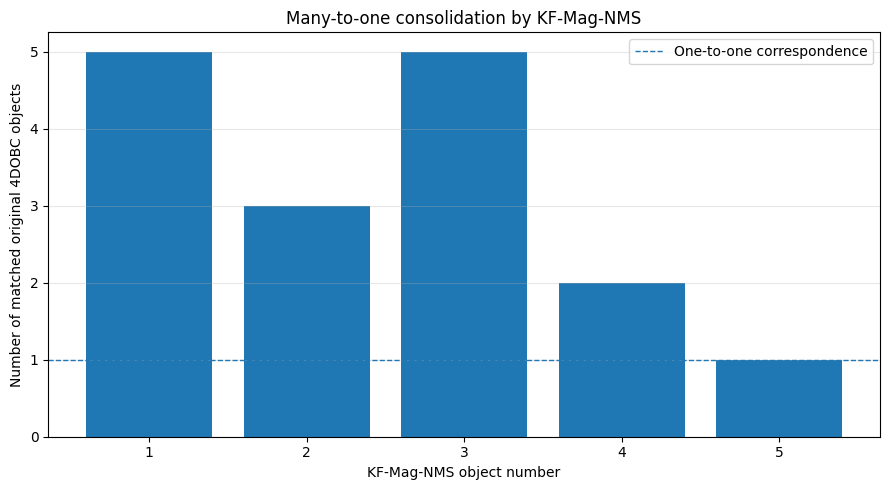

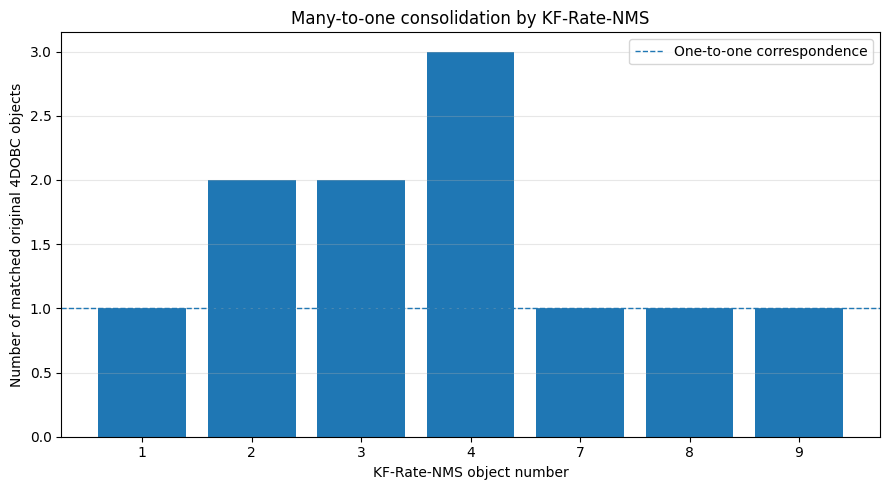

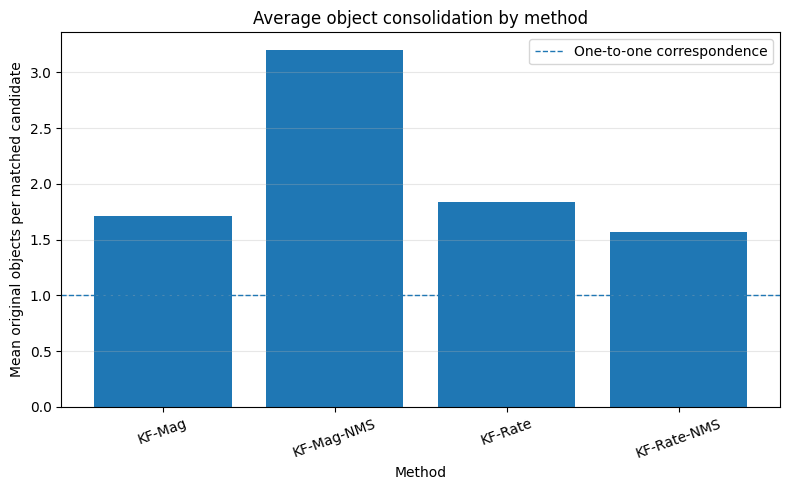

In [27]:
# ============================================================
# CELL 9 — OBJECT CONSOLIDATION AND FRAGMENTATION ANALYSIS
# ============================================================
# Purpose:
#
#   1. Quantify many-to-one and one-to-many relationships:

# ------------------------------------------------------------
# 1. BEST-MATCH TABLE WITH GENUINE SPATIOTEMPORAL OVERLAP
# ------------------------------------------------------------

valid_best_matches = (
    best_matches[
        (
            best_matches[
                "temporal_overlap_epochs"
            ]
            > 0
        )
        &
        (
            best_matches[
                "spatial_overlap_corepoints"
            ]
            > 0
        )
    ]
    .copy()
)


print(
    "Valid best-ranked spatiotemporal matches:",
    len(
        valid_best_matches
    )
)


# ============================================================
# 2. MANY-TO-ONE CONSOLIDATION
# ============================================================
# Count how many original 4DOBC objects select the same
# Kalman object as their best correspondence.

consolidation_table = (
    valid_best_matches
    .groupby(
        [
            "candidate_method",
            "candidate_object",
        ]
    )
    .agg(

        n_original_4dobc_objects=(
            "reference_object",
            "nunique"
        ),

        original_4dobc_objects=(
            "reference_object",
            lambda values:
                ", ".join(
                    map(
                        str,
                        sorted(
                            set(
                                values
                            )
                        )
                    )
                )
        ),

        mean_temporal_overlap_epochs=(
            "temporal_overlap_epochs",
            "mean"
        ),

        mean_spatial_overlap_corepoints=(
            "spatial_overlap_corepoints",
            "mean"
        ),

        mean_temporal_iou=(
            "temporal_iou",
            "mean"
        ),

        mean_spatial_iou=(
            "spatial_iou",
            "mean"
        ),
    )
    .reset_index()
)


consolidation_table = (
    consolidation_table
    .sort_values(
        [
            "candidate_method",
            "n_original_4dobc_objects",
        ],
        ascending=[
            True,
            False,
        ]
    )
    .reset_index(
        drop=True
    )
)


print(
    "\n=========================================="
)

print(
    "MANY-TO-ONE CONSOLIDATION"
)

print(
    "=========================================="
)


display(
    consolidation_table
)


# ============================================================
# 3. METHOD-LEVEL CONSOLIDATION SUMMARY
# ============================================================

consolidation_summary = (
    consolidation_table
    .groupby(
        "candidate_method"
    )
    .agg(

        n_candidate_objects_with_matches=(
            "candidate_object",
            "nunique"
        ),

        max_original_objects_per_candidate=(
            "n_original_4dobc_objects",
            "max"
        ),

        mean_original_objects_per_candidate=(
            "n_original_4dobc_objects",
            "mean"
        ),

        n_consolidating_objects=(
            "n_original_4dobc_objects",
            lambda values:
                int(
                    np.sum(
                        np.asarray(
                            values
                        )
                        > 1
                    )
                )
        ),
    )
    .reset_index()
)


display(
    consolidation_summary
)


# ============================================================
# 4. ONE-TO-MANY FRAGMENTATION
# ============================================================
# Use ALL candidate pairs from match_table rather than only
# the best-ranked candidate.
#
# This determines how many Kalman objects have both spatial
# and temporal overlap with each original 4DOBC object.

valid_all_matches = (
    match_table[
        (
            match_table[
                "temporal_overlap_epochs"
            ]
            > 0
        )
        &
        (
            match_table[
                "spatial_overlap_corepoints"
            ]
            > 0
        )
    ]
    .copy()
)


fragmentation_table = (
    valid_all_matches
    .groupby(
        [
            "candidate_method",
            "reference_object",
        ]
    )
    .agg(

        n_overlapping_candidate_objects=(
            "candidate_object",
            "nunique"
        ),

        overlapping_candidate_objects=(
            "candidate_object",
            lambda values:
                ", ".join(
                    map(
                        str,
                        sorted(
                            set(
                                values
                            )
                        )
                    )
                )
        ),

        maximum_temporal_overlap_epochs=(
            "temporal_overlap_epochs",
            "max"
        ),

        maximum_spatial_overlap_corepoints=(
            "spatial_overlap_corepoints",
            "max"
        ),
    )
    .reset_index()
)


fragmentation_table = (
    fragmentation_table
    .sort_values(
        [
            "candidate_method",
            "reference_object",
        ]
    )
    .reset_index(
        drop=True
    )
)


print(
    "\n=========================================="
)

print(
    "ONE-TO-MANY FRAGMENTATION"
)

print(
    "=========================================="
)


display(
    fragmentation_table
)


# ============================================================
# 5. METHOD-LEVEL FRAGMENTATION SUMMARY
# ============================================================

fragmentation_summary = (
    fragmentation_table
    .groupby(
        "candidate_method"
    )
    .agg(

        n_reference_objects_with_matches=(
            "reference_object",
            "nunique"
        ),

        mean_candidates_per_reference=(
            "n_overlapping_candidate_objects",
            "mean"
        ),

        max_candidates_per_reference=(
            "n_overlapping_candidate_objects",
            "max"
        ),

        n_fragmented_reference_objects=(
            "n_overlapping_candidate_objects",
            lambda values:
                int(
                    np.sum(
                        np.asarray(
                            values
                        )
                        > 1
                    )
                )
        ),
    )
    .reset_index()
)


display(
    fragmentation_summary
)


# ============================================================
# 6. VISUALIZATION — KF-MAG-NMS CONSOLIDATION
# ============================================================

plot_table_mag_nms = (
    consolidation_table[
        consolidation_table[
            "candidate_method"
        ]
        == "KF-Mag-NMS"
    ]
    .copy()
)


plot_table_mag_nms = (
    plot_table_mag_nms
    .sort_values(
        "candidate_object"
    )
)


if len(
    plot_table_mag_nms
) > 0:

    plt.figure(
        figsize=(
            9,
            5
        )
    )


    plt.bar(
        plot_table_mag_nms[
            "candidate_object"
        ].astype(
            str
        ),

        plot_table_mag_nms[
            "n_original_4dobc_objects"
        ]
    )


    plt.axhline(
        1,
        linestyle="--",
        linewidth=1,
        label="One-to-one correspondence"
    )


    plt.xlabel(
        "KF-Mag-NMS object number"
    )

    plt.ylabel(
        "Number of matched original 4DOBC objects"
    )

    plt.title(
        "Many-to-one consolidation by KF-Mag-NMS"
    )

    plt.legend()

    plt.grid(
        axis="y",
        alpha=0.3
    )

    plt.tight_layout()

    plt.show()


# ============================================================
# 7. VISUALIZATION — KF-RATE-NMS CONSOLIDATION
# ============================================================

plot_table_rate_nms = (
    consolidation_table[
        consolidation_table[
            "candidate_method"
        ]
        == "KF-Rate-NMS"
    ]
    .copy()
)


plot_table_rate_nms = (
    plot_table_rate_nms
    .sort_values(
        "candidate_object"
    )
)


if len(
    plot_table_rate_nms
) > 0:

    plt.figure(
        figsize=(
            9,
            5
        )
    )


    plt.bar(
        plot_table_rate_nms[
            "candidate_object"
        ].astype(
            str
        ),

        plot_table_rate_nms[
            "n_original_4dobc_objects"
        ]
    )


    plt.axhline(
        1,
        linestyle="--",
        linewidth=1,
        label="One-to-one correspondence"
    )


    plt.xlabel(
        "KF-Rate-NMS object number"
    )

    plt.ylabel(
        "Number of matched original 4DOBC objects"
    )

    plt.title(
        "Many-to-one consolidation by KF-Rate-NMS"
    )

    plt.legend()

    plt.grid(
        axis="y",
        alpha=0.3
    )

    plt.tight_layout()

    plt.show()


# ============================================================
# 8. VISUALIZATION — METHOD-LEVEL CONSOLIDATION
# ============================================================

plt.figure(
    figsize=(
        8,
        5
    )
)


plt.bar(
    consolidation_summary[
        "candidate_method"
    ],

    consolidation_summary[
        "mean_original_objects_per_candidate"
    ]
)


plt.axhline(
    1,
    linestyle="--",
    linewidth=1,
    label="One-to-one correspondence"
)


plt.xlabel(
    "Method"
)

plt.ylabel(
    "Mean original objects per matched candidate"
)

plt.title(
    "Average object consolidation by method"
)

plt.xticks(
    rotation=20
)

plt.legend()

plt.grid(
    axis="y",
    alpha=0.3
)

plt.tight_layout()

plt.show()


# ============================================================
# 9. SAVE RESULTS
# ============================================================

consolidation_table.to_csv(
    EVALUATION_DIR
    / "object_consolidation_table.csv",
    index=False
)


consolidation_summary.to_csv(
    EVALUATION_DIR
    / "object_consolidation_summary.csv",
    index=False
)


fragmentation_table.to_csv(
    EVALUATION_DIR
    / "object_fragmentation_table.csv",
    index=False
)


fragmentation_summary.to_csv(
    EVALUATION_DIR
    / "object_fragmentation_summary.csv",
    index=False
)


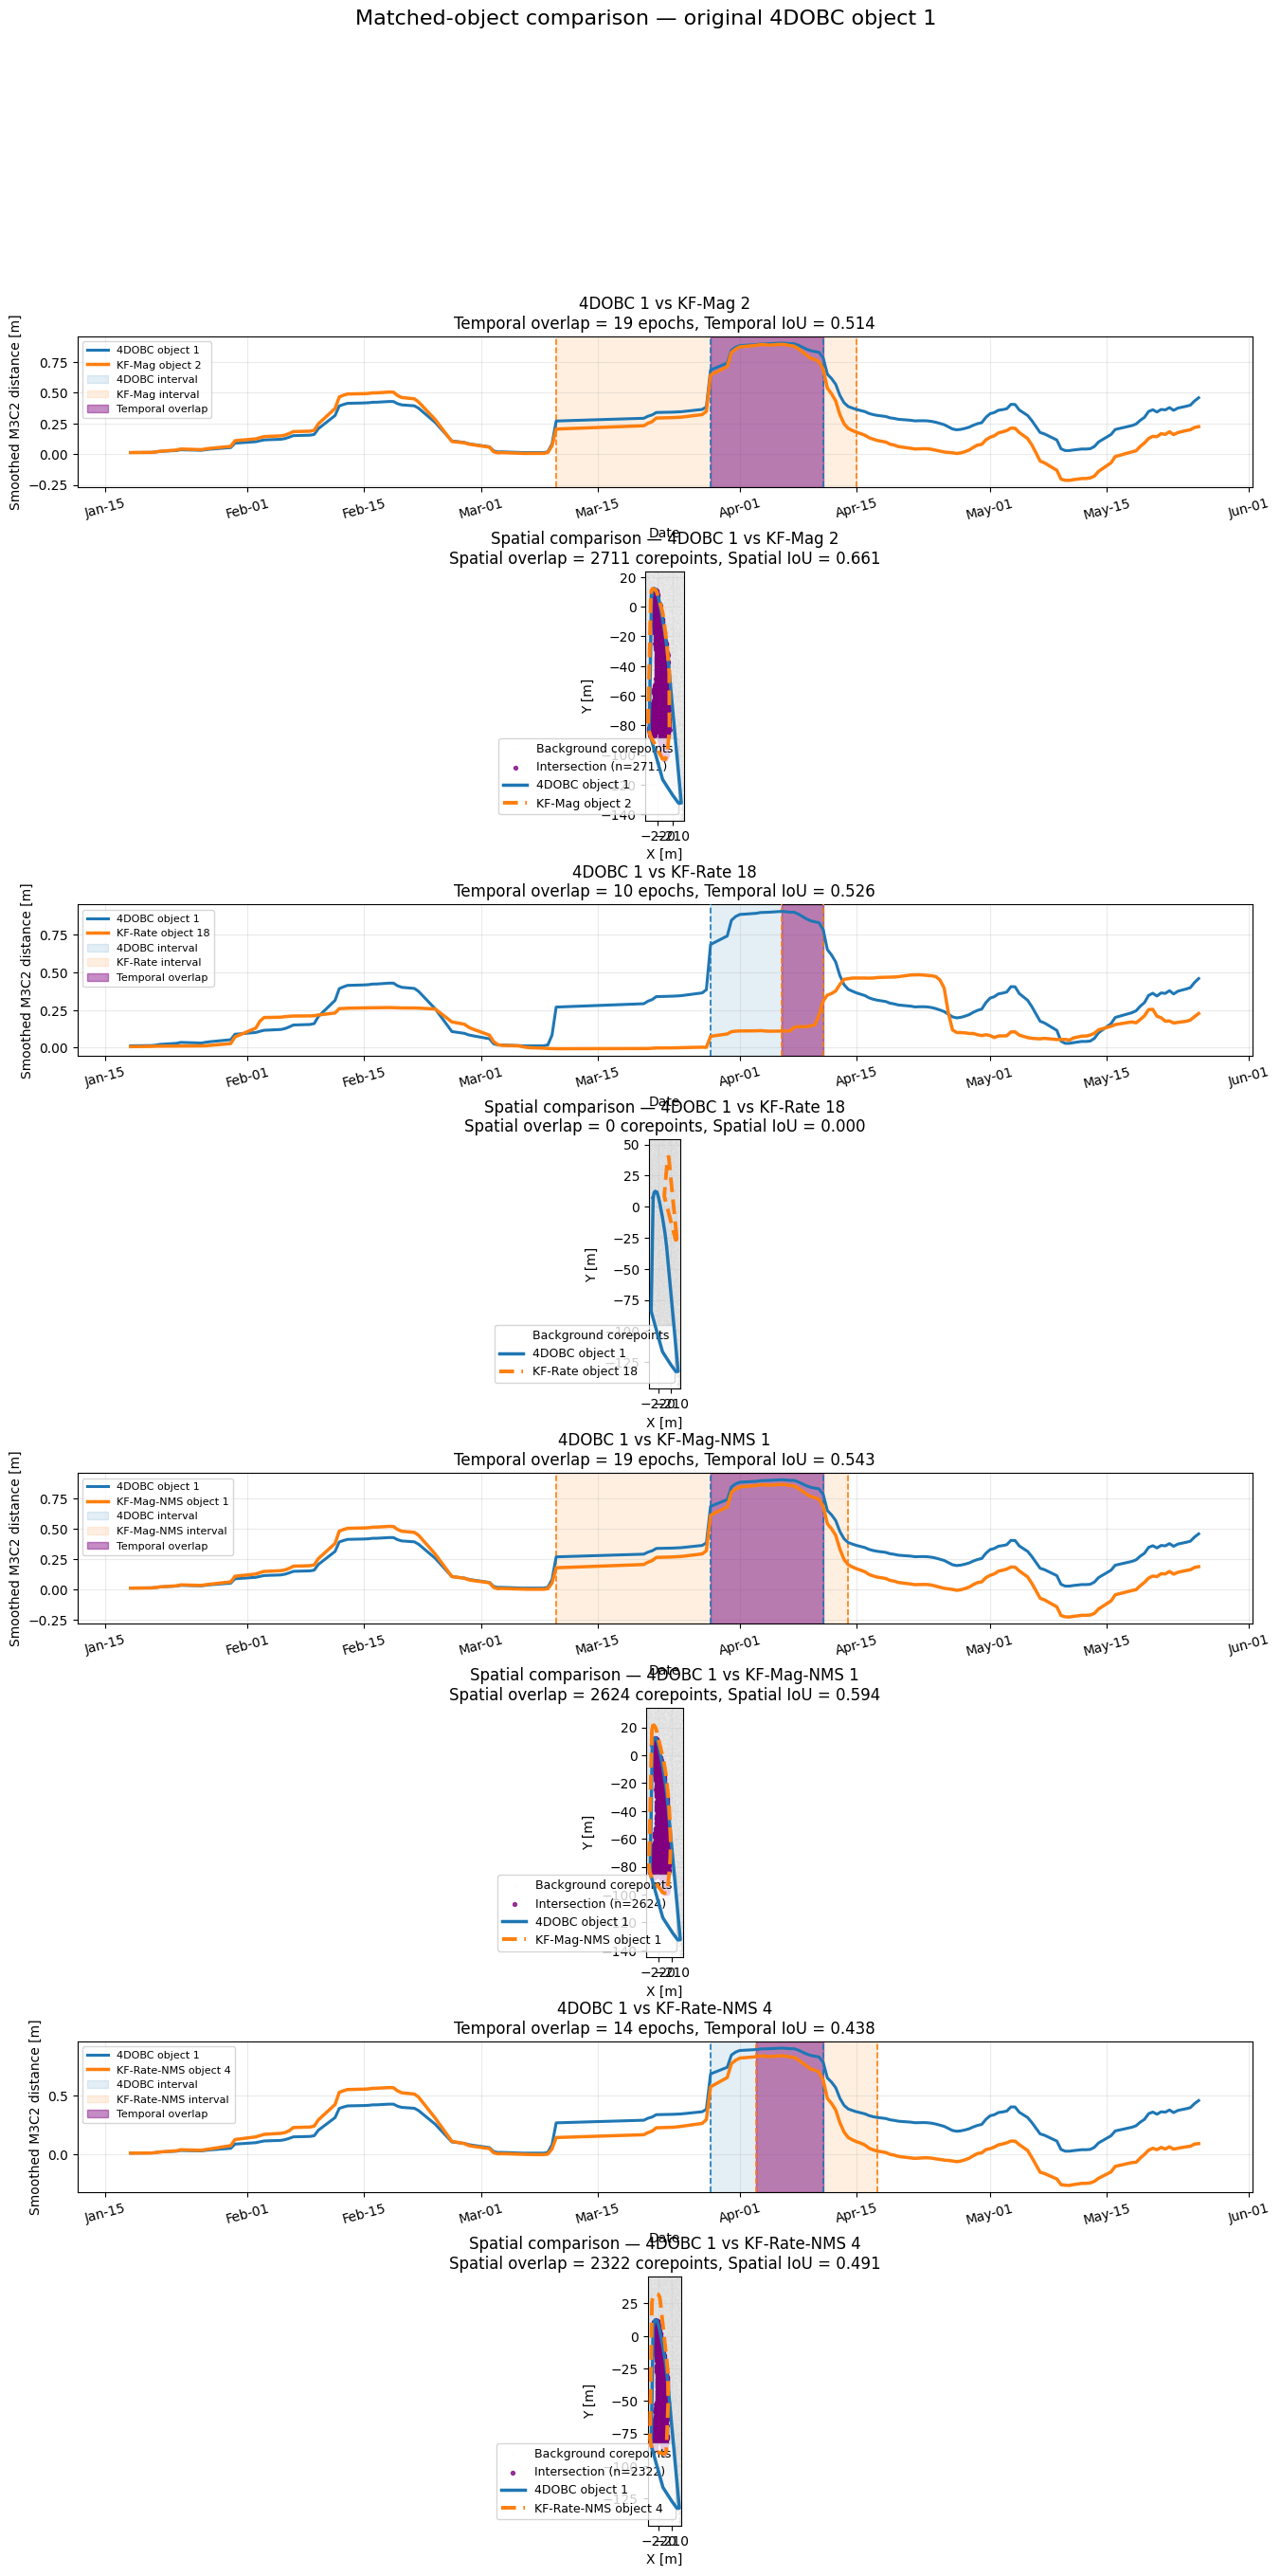


Best-ranked matches for 4DOBC object 1:


,candidate_method,candidate_object,temporal_overlap_epochs,spatial_overlap_corepoints,temporal_iou,spatial_iou
0,KF-Mag,2,19,2711,0.513514,0.661381
1,KF-Mag-NMS,1,19,2624,0.542857,0.593934
2,KF-Rate,18,10,0,0.526316,0.000000
3,KF-Rate-NMS,4,14,2322,0.437500,0.491221


In [28]:
# ============================================================
# CELL 10 — VISUAL COMPARISON OF MATCHED OBJECTS
# ============================================================
# Purpose:
#
# Visually compare one original 4DOBC object with its
# best-ranked objects from:
# ============================================================

# ------------------------------------------------------------
# 0. IMPORTS
# ------------------------------------------------------------

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

from scipy.spatial import ConvexHull


# ------------------------------------------------------------
# 1. USER SETTING
# ------------------------------------------------------------

OBJECT_NUMBER = 1


if OBJECT_NUMBER < 1:
    raise ValueError(
        "OBJECT_NUMBER must start from 1."
    )


# ------------------------------------------------------------
# 2. VISUAL STYLE
# ------------------------------------------------------------

COLOR_4DOBC = "tab:blue"
COLOR_CANDIDATE = "tab:orange"
COLOR_OVERLAP = "purple"
COLOR_BACKGROUND = "lightgray"

LINEWIDTH_4DOBC = 2.2
LINEWIDTH_CANDIDATE = 2.5

INTERVAL_ALPHA = 0.12
TEMPORAL_OVERLAP_ALPHA = 0.45
SPATIAL_OVERLAP_ALPHA = 0.75


# ------------------------------------------------------------
# 3. METHODS TO COMPARE
# ------------------------------------------------------------

METHODS_TO_COMPARE = [
    "KF-Mag",
    "KF-Rate",
    "KF-Mag-NMS",
    "KF-Rate-NMS",
]


# ------------------------------------------------------------
# 4. HELPER — DRAW SPATIAL OUTLINE
# ------------------------------------------------------------

def draw_object_outline(
    ax,
    xy,
    color,
    linestyle,
    linewidth,
    label,
    zorder
):
    """
    Draw a convex-hull visualization of an object's XY
    corepoints.

    The hull is used only for visualization and does not
    define the spatial-overlap metric.
    """

    xy = np.asarray(
        xy,
        dtype=float
    )


    xy = xy[
        np.all(
            np.isfinite(
                xy
            ),
            axis=1
        )
    ]


    xy = np.unique(
        xy,
        axis=0
    )


    if len(xy) < 3:

        ax.scatter(
            xy[:, 0],
            xy[:, 1],
            color=color,
            s=8,
            label=label,
            zorder=zorder
        )

        return


    try:

        hull = ConvexHull(
            xy
        )


        hull_xy = xy[
            hull.vertices
        ]


        hull_xy = np.vstack(
            [
                hull_xy,
                hull_xy[0]
            ]
        )


        line, = ax.plot(
            hull_xy[:, 0],
            hull_xy[:, 1],
            color=color,
            linewidth=linewidth,
            linestyle=linestyle,
            label=label,
            zorder=zorder
        )


        # Short dashed appearance for Kalman candidate
        if linestyle == "--":

            line.set_dashes(
                [4, 2]
            )


    except Exception:

        ax.scatter(
            xy[:, 0],
            xy[:, 1],
            color=color,
            s=8,
            label=label,
            zorder=zorder
        )


# ------------------------------------------------------------
# 5. GET ORIGINAL 4DOBC OBJECT
# ------------------------------------------------------------

reference_object = (
    get_saved_object_record(
        method_name="4DOBC",
        object_number=OBJECT_NUMBER
    )
)


reference_indices = np.asarray(
    reference_object[
        "indices"
    ],
    dtype=int
)


reference_start = int(
    reference_object[
        "start_epoch"
    ]
)


reference_end = int(
    reference_object[
        "end_epoch"
    ]
)


# ------------------------------------------------------------
# 6. GET BEST-RANKED MATCHES
# ------------------------------------------------------------

selected_matches = (
    best_matches[
        best_matches[
            "reference_object"
        ]
        == OBJECT_NUMBER
    ]
    .copy()
)


if len(selected_matches) == 0:

    raise ValueError(
        f"No matches found for original "
        f"4DOBC object {OBJECT_NUMBER}."
    )


# ------------------------------------------------------------
# 7. TIME-SERIES DATA
# ------------------------------------------------------------

signal_data = np.asarray(
    analysis.smoothed_distances
)


reference_mean_ts = np.nanmean(
    signal_data[
        reference_indices,
        :
    ],
    axis=0
)


# ------------------------------------------------------------
# 8. CREATE FIGURE
# ------------------------------------------------------------
# Each method receives two rows:
#
#   row 1 -> temporal comparison
#   row 2 -> enlarged spatial comparison
#
# Spatial row is intentionally taller.
# ------------------------------------------------------------

n_methods = len(
    METHODS_TO_COMPARE
)


fig = plt.figure(
    figsize=(
        16,
        7.5 * n_methods
    )
)


gs = fig.add_gridspec(
    nrows=2 * n_methods,
    ncols=1,

    height_ratios=[
        value

        for _ in range(
            n_methods
        )

        for value in (
            1.0,
            1.65
        )
    ],

    hspace=0.42
)


time_axes = []

space_axes = []


for i in range(
    n_methods
):

    time_axes.append(
        fig.add_subplot(
            gs[
                2 * i,
                0
            ]
        )
    )


    space_axes.append(
        fig.add_subplot(
            gs[
                2 * i + 1,
                0
            ]
        )
    )


# ------------------------------------------------------------
# 9. LOOP THROUGH COMPARISON METHODS
# ------------------------------------------------------------

for row_idx, method_name in enumerate(
    METHODS_TO_COMPARE
):

    ax_time = time_axes[
        row_idx
    ]


    ax_space = space_axes[
        row_idx
    ]


    # --------------------------------------------------------
    # Find best-ranked match for this method
    # --------------------------------------------------------

    method_match = (
        selected_matches[
            selected_matches[
                "candidate_method"
            ]
            == method_name
        ]
    )


    if len(method_match) == 0:

        ax_time.text(
            0.5,
            0.5,
            "No candidate match",
            ha="center",
            va="center",
            transform=ax_time.transAxes
        )


        ax_space.text(
            0.5,
            0.5,
            "No candidate match",
            ha="center",
            va="center",
            transform=ax_space.transAxes
        )


        continue


    method_match = (
        method_match.iloc[0]
    )


    candidate_number = int(
        method_match[
            "candidate_object"
        ]
    )


    candidate_object = (
        get_saved_object_record(
            method_name=method_name,
            object_number=candidate_number
        )
    )


    candidate_indices = np.asarray(
        candidate_object[
            "indices"
        ],
        dtype=int
    )


    candidate_start = int(
        candidate_object[
            "start_epoch"
        ]
    )


    candidate_end = int(
        candidate_object[
            "end_epoch"
        ]
    )


    candidate_mean_ts = np.nanmean(
        signal_data[
            candidate_indices,
            :
        ],
        axis=0
    )


    # ========================================================
    # TEMPORAL PANEL
    # ========================================================

    # --------------------------------------------------------
    # Original 4DOBC mean time series
    # --------------------------------------------------------

    ax_time.plot(
        timestamps_analysis,
        reference_mean_ts,
        color=COLOR_4DOBC,
        linewidth=LINEWIDTH_4DOBC,
        label=(
            f"4DOBC object "
            f"{OBJECT_NUMBER}"
        ),
        zorder=5
    )


    # --------------------------------------------------------
    # Kalman candidate mean time series
    # --------------------------------------------------------

    ax_time.plot(
        timestamps_analysis,
        candidate_mean_ts,
        color=COLOR_CANDIDATE,
        linewidth=LINEWIDTH_CANDIDATE,
        label=(
            f"{method_name} object "
            f"{candidate_number}"
        ),
        zorder=6
    )


    # --------------------------------------------------------
    # Original 4DOBC temporal interval
    # --------------------------------------------------------

    ax_time.axvspan(
        timestamps_analysis[
            reference_start
        ],
        timestamps_analysis[
            reference_end
        ],
        color=COLOR_4DOBC,
        alpha=INTERVAL_ALPHA,
        label="4DOBC interval",
        zorder=1
    )


    ax_time.axvline(
        timestamps_analysis[
            reference_start
        ],
        color=COLOR_4DOBC,
        linestyle="--",
        linewidth=1.2,
        zorder=3
    )


    ax_time.axvline(
        timestamps_analysis[
            reference_end
        ],
        color=COLOR_4DOBC,
        linestyle="--",
        linewidth=1.2,
        zorder=3
    )


    # --------------------------------------------------------
    # Kalman candidate temporal interval
    # --------------------------------------------------------

    ax_time.axvspan(
        timestamps_analysis[
            candidate_start
        ],
        timestamps_analysis[
            candidate_end
        ],
        color=COLOR_CANDIDATE,
        alpha=INTERVAL_ALPHA,
        label=(
            f"{method_name} interval"
        ),
        zorder=1
    )


    ax_time.axvline(
        timestamps_analysis[
            candidate_start
        ],
        color=COLOR_CANDIDATE,
        linestyle="--",
        linewidth=1.2,
        zorder=3
    )


    ax_time.axvline(
        timestamps_analysis[
            candidate_end
        ],
        color=COLOR_CANDIDATE,
        linestyle="--",
        linewidth=1.2,
        zorder=3
    )


    # --------------------------------------------------------
    # Temporal overlap
    # --------------------------------------------------------

    overlap_start = max(
        reference_start,
        candidate_start
    )


    overlap_end = min(
        reference_end,
        candidate_end
    )


    if overlap_start <= overlap_end:

        ax_time.axvspan(
            timestamps_analysis[
                overlap_start
            ],
            timestamps_analysis[
                overlap_end
            ],
            color=COLOR_OVERLAP,
            alpha=TEMPORAL_OVERLAP_ALPHA,
            label="Temporal overlap",
            zorder=2
        )


    # --------------------------------------------------------
    # Temporal formatting
    # --------------------------------------------------------

    ax_time.xaxis.set_major_formatter(
        mdates.DateFormatter(
            "%b-%d"
        )
    )


    ax_time.tick_params(
        axis="x",
        rotation=15
    )


    ax_time.set_xlabel(
        "Date"
    )


    ax_time.set_ylabel(
        "Smoothed M3C2 distance [m]"
    )


    ax_time.set_title(
        f"4DOBC {OBJECT_NUMBER} vs "
        f"{method_name} {candidate_number}\n"
        f"Temporal overlap = "
        f"{int(method_match['temporal_overlap_epochs'])} epochs, "
        f"Temporal IoU = "
        f"{method_match['temporal_iou']:.3f}"
    )


    ax_time.grid(
        True,
        alpha=0.25
    )


    ax_time.legend(
        fontsize=8,
        loc="best"
    )


    # ========================================================
    # SPATIAL PANEL
    # ========================================================

    # --------------------------------------------------------
    # Object coordinates
    # --------------------------------------------------------

    reference_xy = corepoints[
        reference_indices,
        :2
    ]


    candidate_xy = corepoints[
        candidate_indices,
        :2
    ]


    intersection_indices = np.intersect1d(
        reference_indices,
        candidate_indices
    )


    # --------------------------------------------------------
    # Determine plot extent from both objects
    # --------------------------------------------------------

    combined_xy = np.vstack(
        [
            reference_xy,
            candidate_xy
        ]
    )


    x_min = np.nanmin(
        combined_xy[
            :,
            0
        ]
    )


    x_max = np.nanmax(
        combined_xy[
            :,
            0
        ]
    )


    y_min = np.nanmin(
        combined_xy[
            :,
            1
        ]
    )


    y_max = np.nanmax(
        combined_xy[
            :,
            1
        ]
    )


    x_range = (
        x_max
        -
        x_min
    )


    y_range = (
        y_max
        -
        y_min
    )


    x_padding = max(
        0.08 * x_range,
        1.0
    )


    y_padding = max(
        0.08 * y_range,
        1.0
    )


    x_plot_min = (
        x_min
        -
        x_padding
    )


    x_plot_max = (
        x_max
        +
        x_padding
    )


    y_plot_min = (
        y_min
        -
        y_padding
    )


    y_plot_max = (
        y_max
        +
        y_padding
    )


    # --------------------------------------------------------
    # Background corepoints inside current zoom window
    # --------------------------------------------------------

    background_mask = (
        (
            corepoints[
                :,
                0
            ]
            >=
            x_plot_min
        )

        &

        (
            corepoints[
                :,
                0
            ]
            <=
            x_plot_max
        )

        &

        (
            corepoints[
                :,
                1
            ]
            >=
            y_plot_min
        )

        &

        (
            corepoints[
                :,
                1
            ]
            <=
            y_plot_max
        )
    )


    ax_space.scatter(
        corepoints[
            background_mask,
            0
        ],
        corepoints[
            background_mask,
            1
        ],
        s=0.3,
        color=COLOR_BACKGROUND,
        alpha=0.12,
        label="Background corepoints",
        zorder=0
    )


    # --------------------------------------------------------
    # Spatial intersection
    # --------------------------------------------------------

    if len(
        intersection_indices
    ) > 0:

        intersection_xy = corepoints[
            intersection_indices,
            :2
        ]


        ax_space.scatter(
            intersection_xy[
                :,
                0
            ],
            intersection_xy[
                :,
                1
            ],
            s=8,
            color=COLOR_OVERLAP,
            alpha=SPATIAL_OVERLAP_ALPHA,
            label=(
                f"Intersection "
                f"(n={len(intersection_indices)})"
            ),
            zorder=4
        )


    # --------------------------------------------------------
    # Original 4DOBC solid outline
    # --------------------------------------------------------

    draw_object_outline(
        ax=ax_space,
        xy=reference_xy,
        color=COLOR_4DOBC,
        linestyle="-",
        linewidth=2.5,
        label=(
            f"4DOBC object "
            f"{OBJECT_NUMBER}"
        ),
        zorder=6
    )


    # --------------------------------------------------------
    # Kalman candidate dashed outline
    # --------------------------------------------------------

    draw_object_outline(
        ax=ax_space,
        xy=candidate_xy,
        color=COLOR_CANDIDATE,
        linestyle="--",
        linewidth=2.8,
        label=(
            f"{method_name} object "
            f"{candidate_number}"
        ),
        zorder=8
    )


    # --------------------------------------------------------
    # Apply spatial zoom
    # --------------------------------------------------------

    ax_space.set_xlim(
        x_plot_min,
        x_plot_max
    )


    ax_space.set_ylim(
        y_plot_min,
        y_plot_max
    )


    # --------------------------------------------------------
    # Spatial formatting
    # --------------------------------------------------------

    ax_space.set_aspect(
        "equal",
        adjustable="box"
    )


    ax_space.set_xlabel(
        "X [m]"
    )


    ax_space.set_ylabel(
        "Y [m]"
    )


    ax_space.set_title(
        f"Spatial comparison — "
        f"4DOBC {OBJECT_NUMBER} vs "
        f"{method_name} {candidate_number}\n"
        f"Spatial overlap = "
        f"{int(method_match['spatial_overlap_corepoints'])} corepoints, "
        f"Spatial IoU = "
        f"{method_match['spatial_iou']:.3f}"
    )


    ax_space.grid(
        True,
        alpha=0.15
    )


    ax_space.legend(
        fontsize=9,
        loc="best"
    )


# ------------------------------------------------------------
# 10. FIGURE TITLE
# ------------------------------------------------------------

fig.suptitle(
    f"Matched-object comparison — "
    f"original 4DOBC object {OBJECT_NUMBER}",
    fontsize=16,
    y=0.995
)


plt.show()


# ------------------------------------------------------------
# 11. DISPLAY MATCH TABLE
# ------------------------------------------------------------

display_columns = [
    "candidate_method",
    "candidate_object",
    "temporal_overlap_epochs",
    "spatial_overlap_corepoints",
    "temporal_iou",
    "spatial_iou",
]


print(
    "\nBest-ranked matches for "
    f"4DOBC object {OBJECT_NUMBER}:"
)


display(
    selected_matches[
        display_columns
    ]
)

In [ ]:
# 11. ...